<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
      Spam Classification-NLP -LSTM
</center></p></h1>

<a class="anchor" id="data"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;"> Libraries
 </font><br>
 <br>   
<br>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Embedding


from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

from sklearn.preprocessing import LabelEncoder


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [2]:
# read dataset (csv -> pandas dataframe)
df = pd.read_csv(r"D:\Data Analysis- Scientist\Projects\Biga Data & NLP\Spam_text_message\SPAM text message 20170820 - Data.csv")
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [3]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [4]:
df.value_counts()

Category  Message                                                                                                                                                
ham       Sorry, I'll call later                                                                                                                                     30
          I cant pick the phone right now. Pls send a message                                                                                                        12
          Ok...                                                                                                                                                      10
          Okie                                                                                                                                                        4
          7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st "Ur Lovely Friendship"... good morning dear     

  category  number
0     spam       0
1      ham       0


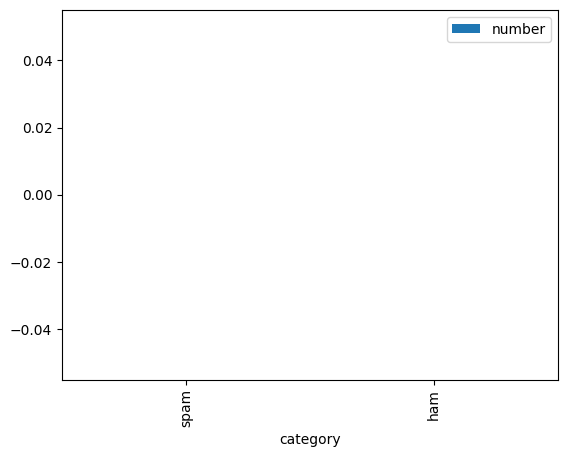

In [8]:
# gain insight from data
data = {'category': ['spam', 'ham'],
        'number': [len(df.loc[df.Category==1]), len(df.loc[df.Category==0])]
        }  
df_count = pd.DataFrame(data,columns=['category', 'number'])
print (df_count)

df_count.plot(x ='category', y='number', kind = 'bar')
plt.show()


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Text Preprocessing 
</center></p></h1>

In [5]:
# cleaning dataset
stemmer = PorterStemmer()
corpus = []

for w in range(len(df['Message'])):
    msg = df['Message'][w]
    msg = re.sub("[^a-zA-Z]", " ", msg)
    msg = msg.lower()
    msg = msg.split()
    msg = [stemmer.stem(word) for word in msg if not word in set(stopwords.words('english'))]
    msg = " ".join(msg)
    corpus.append(msg)

In [7]:
print(corpus)

['go jurong point crazi avail bugi n great world la e buffet cine got amor wat', 'ok lar joke wif u oni', 'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli', 'u dun say earli hor u c alreadi say', 'nah think goe usf live around though', 'freemsg hey darl week word back like fun still tb ok xxx std chg send rcv', 'even brother like speak treat like aid patent', 'per request mell mell oru minnaminungint nurungu vettam set callertun caller press copi friend callertun', 'winner valu network custom select receivea prize reward claim call claim code kl valid hour', 'mobil month u r entitl updat latest colour mobil camera free call mobil updat co free', 'gonna home soon want talk stuff anymor tonight k cri enough today', 'six chanc win cash pound txt csh send cost p day day tsandc appli repli hl info', 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw', 'search right word thank breather promis wont 

In [10]:
X = df["Message"]
y = df["Category"]


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Labeling
</center></p></h1>

In [25]:
le = LabelEncoder()

In [26]:
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test) 

ValueError: invalid literal for int() with base 10: 'ham'

In [12]:
y

array([0, 0, 1, ..., 0, 0, 0])

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     Split/Test
</center></p></h1>

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20, random_state = 0)


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
     create word vector
</center></p></h1>

In [14]:
max_words = 500
tkn = Tokenizer(num_words=max_words)
tkn.fit_on_texts(X_train)
seq = tkn.texts_to_sequences(X_train)
print(seq)

[[38, 31, 56, 12, 5, 9, 14, 47, 36, 1, 207, 8, 127], [36, 3, 203, 21, 51, 1, 29, 138], [17, 3, 26, 184, 47, 403, 208, 62, 4, 298], [1, 32, 60, 81, 168, 21, 3, 93], [425, 39, 21, 52, 153], [10, 31, 25, 352, 1, 33, 270], [54, 67, 164, 9, 25, 5, 11, 291, 119, 229, 9, 70], [132, 157, 7, 11, 32, 52, 5], [84, 38, 17, 60, 292, 250, 2, 28, 254, 34, 8, 99], [333, 16, 3, 478, 333, 119], [105, 1, 17, 404], [60, 14, 14, 2, 311, 3, 46, 113, 312], [9, 64, 12, 1, 35, 194, 12, 201, 38, 12, 135], [8, 86, 325], [59, 498, 35, 214, 34, 209, 46, 5, 282], [499, 79, 299, 15, 46, 15, 250], [286, 93, 178, 31, 8, 165, 1, 190, 139], [1, 59, 18, 5, 140, 2, 27, 81], [251, 47, 1, 8, 2, 158, 184, 7, 95, 164, 104, 8, 21, 3, 219, 44, 375], [300, 2, 362, 7, 255, 77, 20], [58, 293, 24, 141, 2, 96, 210, 23, 215, 216, 12, 135, 7, 14, 210, 30, 217, 230, 99, 218, 94, 9, 4, 3, 60, 479], [50, 208, 2, 19, 64, 11, 150], [286, 31, 51], [403, 26, 5, 230, 11, 334], [121, 21, 3, 3, 164, 3, 176, 34, 109, 45, 1], [38, 110, 1, 17, 141

In [15]:
max_len = 100
padded_docs = pad_sequences(seq, padding = 'pre', maxlen= max_len)
print(padded_docs)

[[  0   0   0 ... 207   8 127]
 [  0   0   0 ...   1  29 138]
 [  0   0   0 ...  62   4 298]
 ...
 [  0   0   0 ... 137 381 346]
 [  0   0   0 ...  19  11 334]
 [  0   0   0 ...  33  20 105]]


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    ML MODELING
</center></p></h1>

In [16]:
embedding_vector_features = 30
model = Sequential()
model.add(Embedding(max_words, embedding_vector_features, input_length=max_len))
model.add(LSTM(256))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [19]:
print(type(padded_docs), padded_docs.dtype)
print(type(y_train), y_train.dtype)

<class 'numpy.ndarray'> int32
<class 'pandas.core.series.Series'> object


In [20]:
y_train = y_train.map({'ham':0, 'spam':1}).astype('int32').values

In [21]:
model.fit(padded_docs,y_train,batch_size=128,epochs=10, validation_split=0.2)

text_seq = tkn.texts_to_sequences(X_test)
test_padded = pad_sequences(text_seq, maxlen = max_len)



Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.8662 - loss: 0.3857 - val_accuracy: 0.9260 - val_loss: 0.2409
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 271ms/step - accuracy: 0.9562 - loss: 0.1588 - val_accuracy: 0.9731 - val_loss: 0.0910
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.9708 - loss: 0.0940 - val_accuracy: 0.9832 - val_loss: 0.0830
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 259ms/step - accuracy: 0.9804 - loss: 0.0709 - val_accuracy: 0.9821 - val_loss: 0.0731
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.9835 - loss: 0.0598 - val_accuracy: 0.9798 - val_loss: 0.0718
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 290ms/step - accuracy: 0.9874 - loss: 0.0503 - val_accuracy: 0.9877 - val_loss: 0.0623
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 297ms/step - accuracy: 0.9896 - loss: 0.0428 - val_accuracy: 0.9877 - val_loss: 0.0570
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.9891 - loss: 0.0400 - val_accuracy: 0

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
   Evaluation
   
</center></p></h1>

In [23]:
accr = model.evaluate(test_padded, y_test)
print(accr)

ValueError: Invalid dtype: object